# TelecomX Churn Analysis

Este projeto consiste na análise dos dados da empresa TelecomX, visando a coleta de insights acerca da taxa de evasão de clientes que a empresa vem enfrentando nos últimos tempo.

Ao final do projeto, foi criado um relatório completo, explicando os insights obtidos durante a análise e visualização dos dados.

## O Contexto:

A Telecom X enfrenta atualmente um alto índice de cancelamentos de seus serviços, o que tem impactado diretamente sua receita e crescimento. 

A empresa não possui informações claras sobre os fatores que levam os clientes a deixar a operadora, dificultando o desenvolvimento de estratégias eficientes para retenção.

Para enfrentar esse desafio, é necessário coletar, tratar e analisar os dados dos clientes. Com uma análise exploratória bem estruturada, será possível identificar padrões e tendências que explicam o comportamento de evasão, oferecendo insights estratégicos para que a equipe de Data Science desenvolva modelos preditivos e soluções para reduzir o churn.

## Etapas do projeto
1. Extração dos dados

## Imports

In [1]:
import pandas as pd 
import requests 
import json
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
from IPython.display import display

## Etapa 01 - Extração dos dados

Para iniciarmos a análise, vamos importar os dados da API da Telecom X.

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

dados = requests.get(url)
dados_carregados = json.loads(dados.text)
dados_carregados

[{'customerID': '0002-ORFBO',
  'Churn': 'No',
  'customer': {'gender': 'Female',
   'SeniorCitizen': 0,
   'Partner': 'Yes',
   'Dependents': 'Yes',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'Yes',
   'DeviceProtection': 'No',
   'TechSupport': 'Yes',
   'StreamingTV': 'Yes',
   'StreamingMovies': 'No'},
  'account': {'Contract': 'One year',
   'PaperlessBilling': 'Yes',
   'PaymentMethod': 'Mailed check',
   'Charges': {'Monthly': 65.6, 'Total': '593.3'}}},
 {'customerID': '0003-MKNFE',
  'Churn': 'No',
  'customer': {'gender': 'Male',
   'SeniorCitizen': 0,
   'Partner': 'No',
   'Dependents': 'No',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'Yes'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'No',
   'DeviceProtection': 'No',
   'TechSupport': 'No',
   'StreamingTV': 'No',
   'StreamingMovies': 

In [3]:
pd.DataFrame(dados_carregados)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


### Normalização dos dados do DataFrame

Os dados não estão normalizados. Há muitas colunas que estão com dados aninhados em dicionários.

Para iniciar nossa análise dos dados, precisamos normalizar os dados do DataFrame.

In [4]:
df_telecomx_normalizado = pd.json_normalize(dados_carregados, sep="_")
df_telecomx_normalizado

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


### Ajustando os nomes das colunas

Após a normalização, as nossas colunas ficaram com os prefixos:
- `customer_`
- `internet_`
- `phone_`
- `account_`

Para facilitar na análise e identificação das colunas, vamos remover esses prefixos.

In [5]:
df_telecomx_normalizado.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [6]:
df_telecomx_normalizado.columns = df_telecomx_normalizado.columns.str.replace('customer_', '', regex=False)
df_telecomx_normalizado.columns = df_telecomx_normalizado.columns.str.replace('internet_', '', regex=False)
df_telecomx_normalizado.columns = df_telecomx_normalizado.columns.str.replace('phone_', '', regex=False)
df_telecomx_normalizado.columns = df_telecomx_normalizado.columns.str.replace('account_', '', regex=False)

df_telecomx = df_telecomx_normalizado
df_telecomx.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Com o DataFrame normalizado, podemos iniciar nossa análise.

## Etapa 02 - Tratando os dados 

In [7]:
df_telecomx.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
df_telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Temos no nosso DataFrame as seguintes colunas:

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa 
* `gender`: gênero (masculino e feminino) 
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos 
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico 
* `MultipleLines`: assisnatura de mais de uma linha de telefone 
* `InternetService`: assinatura de um provedor internet 
* `OnlineSecurity`: assinatura adicional de segurança online 
* `OnlineBackup`: assinatura adicional de backup online 
* `DeviceProtection`: assinatura adicional de proteção no dispositivo 
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo 
* `StreamingMovies`: assinatura de streaming de filmes 
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

### Verificando a quantidade de linhas x colunas do nosso DataFrame

In [9]:
df_telecomx.shape

(7267, 21)

### Verificando se há dados nulos

In [10]:
df_telecomx.isnull().sum()

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges_Monthly     0
Charges_Total       0
dtype: int64

In [11]:
df_telecomx.isna().sum()

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges_Monthly     0
Charges_Total       0
dtype: int64

Vamos agora visualizar, por meio de um Heatmap, a presença de dados nulos nesse DataFrame

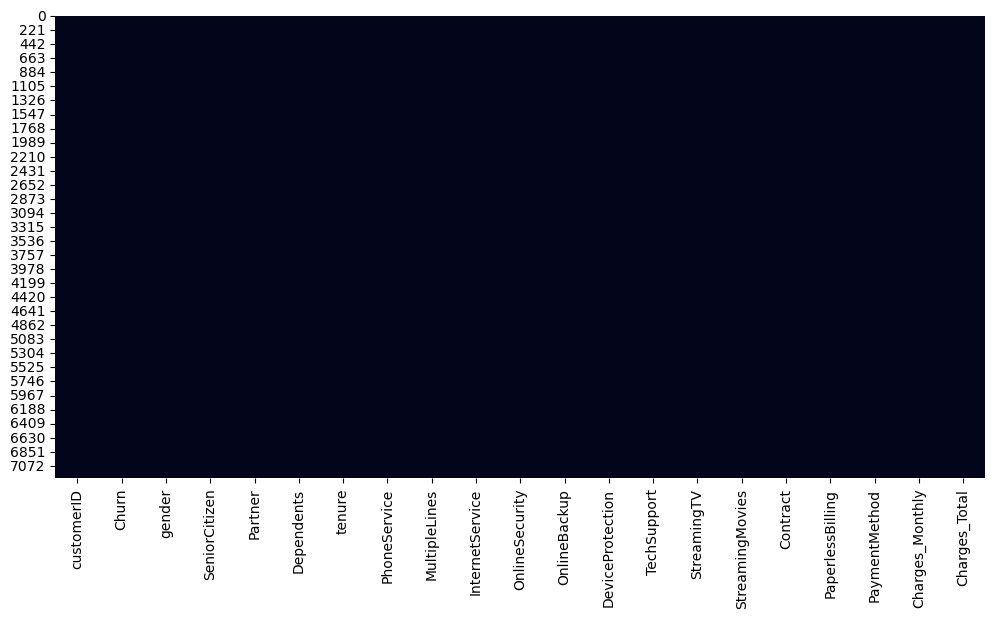

In [12]:
plt.figure(figsize=(12,6))
sns.heatmap(df_telecomx.isnull(), cbar=False)
plt.show()

#### Não há valores nulos no DataFrame, porém, pode ter valores vazios `''`. Vamos verificar.

Para verificar, vamos substituir todos os valores vazios por 'NaN', e então verificar.

In [13]:
df_telecomx = df_telecomx.replace('', None)
df_telecomx = df_telecomx.replace(' ', None)

In [14]:
df_telecomx.isnull().sum()

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Charges_Monthly       0
Charges_Total        11
dtype: int64

Nosso DataFrame possui valores nulos.

- 224 na coluna `Churn`
- 11 na coluna `Charges_Total`

No total temos 235 valores nulos. Nosso dataset possui 7267 registros, em 21 colunas.

A quantidade de valores nulos corresponde a aproximadamente 3.2% do nosso dataset.

Como a maior parte desses valores nulos são na coluna de Churn, nós não podemos simplesmente substituir os valores nulos por "Yes" ou "No", visto que isso poderia facilmente enviesar nossa análise. Com isso, iremos remover os 224 valores nulos da coluna Churn.

Quanto aos valores nulos de Charges_Total, precisamos tomar um pouco de cuidado, visto que essa coluna, visto que ela conversa diretamente com a coluna `tenure` (meses de contrato do cliente) e com `Charges_Monthly` (valor do serviço da TelecomX que cliente paga por mês). 

Vamos fazer uma análise da relação entre as colunas que conversam com Charges_Total, para então tomarmos uma decisão coerente sobre o que fazer com os 11 dados nulos dessa coluna.

In [15]:
df_telecomx[['Churn','tenure', 'Charges_Monthly', 'Charges_Total']].query("`tenure` == 0")

,Churn,tenure,Charges_Monthly,Charges_Total
975,No,0,56.05,None
1775,No,0,20.00,None
1955,No,0,61.90,None
2075,No,0,19.70,None
2232,No,0,20.25,None
2308,No,0,25.35,None
2930,No,0,73.35,None
3134,No,0,25.75,None
3203,No,0,52.55,None
4169,No,0,80.85,None


Como podemos ver na consulta, todos os registros de `Charges_Total` (ou seja, total pago pelo cliente até o momento) que são nulos, possuem um `tenure` igual a 0.

#### O que isso significa? 
- `tenure=0` significa que o cliente não possui tempo de contrato ainda. Ou seja, ele é um cliente novo.
- no contexto do nosso dataset, o `Charges_Total` é o produto de `tenure * Charges_Monthly`, ou seja, quanto o cliente pagou até o momento no tempo de contrato dele.
- Diante disso, podemos assumir que esses clientes AINDA não pagaram nada para a TelecomX, justamente por serem clientes novos.
- Consequentemente, eles não contam como se tivessem cancelado o contrato com a TelecomX.
- Com isso, podemos simplesmente substituir esses valores nulos por 0.

#### Tratando os valores nulos encontrados

In [16]:
df_telecomx = df_telecomx.dropna(subset=['Churn'])
df_telecomx['Churn'].isnull().sum()

0

In [17]:
df_telecomx['Charges_Total'] = df_telecomx['Charges_Total'].fillna(0)
df_telecomx['Charges_Total'].isnull().sum()

0

In [18]:
df_telecomx['Charges_Total'].dtype

dtype('O')

In [19]:
df_telecomx['Charges_Total'] = df_telecomx['Charges_Total'].astype('float64')
df_telecomx['Charges_Total'].dtype

dtype('float64')

### Verificando se há dados duplicados na nossa base de dados

In [20]:
df_telecomx.duplicated().sum()

0

### Verificando a existência de outras inconsistências nas nossas variáveis

Vamos verificar se há mais inconsistências nas variáveis do nosso dataset, principalmente nas variáveis categóricas.

Para isso, vamos separar as variáveis numéricas das demais variáveis categóricas

Vamos primeiro criar um DataFrame separado apenas com as colunas que queremos separar, sem a coluna de Churn e ID.

In [21]:
df_separar_variaveis = df_telecomx.drop(['customerID', 'Churn'], axis=1)
df_separar_variaveis

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [22]:
numericas = df_separar_variaveis.select_dtypes(include=['int64', 'float64']).columns
categoricas = df_separar_variaveis.select_dtypes(include='object').columns

In [23]:
numericas

Index(['SeniorCitizen', 'tenure', 'Charges_Monthly', 'Charges_Total'], dtype='object')

In [24]:
categoricas

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [25]:
for col in categoricas:
    print(f"\n===== {col} =====")
    print("Valores únicos:", df_telecomx[col].unique())
    print("Quantidade de categorias:", df_telecomx[col].nunique())
    print("Valores nulos:", df_telecomx[col].isnull().sum())


===== gender =====
Valores únicos: ['Female' 'Male']
Quantidade de categorias: 2
Valores nulos: 0

===== Partner =====
Valores únicos: ['Yes' 'No']
Quantidade de categorias: 2
Valores nulos: 0

===== Dependents =====
Valores únicos: ['Yes' 'No']
Quantidade de categorias: 2
Valores nulos: 0

===== PhoneService =====
Valores únicos: ['Yes' 'No']
Quantidade de categorias: 2
Valores nulos: 0

===== MultipleLines =====
Valores únicos: ['No' 'Yes' 'No phone service']
Quantidade de categorias: 3
Valores nulos: 0

===== InternetService =====
Valores únicos: ['DSL' 'Fiber optic' 'No']
Quantidade de categorias: 3
Valores nulos: 0

===== OnlineSecurity =====
Valores únicos: ['No' 'Yes' 'No internet service']
Quantidade de categorias: 3
Valores nulos: 0

===== OnlineBackup =====
Valores únicos: ['Yes' 'No' 'No internet service']
Quantidade de categorias: 3
Valores nulos: 0

===== DeviceProtection =====
Valores únicos: ['No' 'Yes' 'No internet service']
Quantidade de categorias: 3
Valores nulos: 0

Com isso, não há inconsistências, valores nulos ou dados repetidos no nosso dataset.

Por fim, uma última alteração que podemos fazer, é converter todos os valores para `lower()`, o que irá facilitar nossa análise e uma futura implementação de um algoritmo de Machine Learning.

In [26]:
df_telecomx[categoricas] = df_telecomx[categoricas].apply(lambda x: x.str.lower())
df_telecomx

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.60,593.30
1,0003-MKNFE,No,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.90,542.40
2,0004-TLHLJ,Yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.90,280.85
3,0011-IGKFF,Yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,female,0,no,no,13,yes,no,dsl,...,no,no,yes,no,no,one year,no,mailed check,55.15,742.90
7263,9992-RRAMN,Yes,male,0,yes,no,22,yes,yes,fiber optic,...,no,no,no,no,yes,month-to-month,yes,electronic check,85.10,1873.70
7264,9992-UJOEL,No,male,0,no,no,2,yes,no,dsl,...,yes,no,no,no,no,month-to-month,yes,mailed check,50.30,92.75
7265,9993-LHIEB,No,male,0,yes,yes,67,yes,no,dsl,...,no,yes,yes,no,yes,two year,no,mailed check,67.85,4627.65


### Quais são as colunas mais importantes para a nossa análise?

Boa parte das colunas do nosso DataFrame são objetos, algumas do tipo `int64` e `float64`. 

Como temos as nossas variáveis numéricas e categóricas já separadas, vamos fazer:
- Cálculo de correlação das variáveis numéricas com o Churn
- Cálculo de média das variáveis categóricas com o Churn

Com esses resultados, poderemos então descobrir, estatisticamente, quais são as variáveis que mais influenciam no Churn e quais são desnecessárias para a nossa análise.

### Calculando a média das variáveis numéricas com o Churn

Antes de fazer o cálculo, vamos converter os valores da nossa variável de Churn para 1 (quando for Yes) e 0 (quando for No). 

Por ser uma coluna categórica binária, podemos fazer essa conversão. 

In [27]:
df_telecomx['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [28]:
df_telecomx['Churn'] = df_telecomx['Churn'].map({'Yes': 1, 'No': 0})
df_telecomx['Churn'].unique()

array([0, 1], dtype=int64)

In [29]:
df_telecomx['Churn'] = df_telecomx['Churn'].astype('int64')

In [30]:
df_telecomx.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,0,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,0003-MKNFE,0,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,0004-TLHLJ,1,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-IGKFF,1,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-EXCHZ,1,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


#### Correlação (variáveis numéricas)

In [31]:
df_telecomx[numericas].corrwith(df_telecomx['Churn'])

SeniorCitizen      0.150889
tenure            -0.352229
Charges_Monthly    0.193356
Charges_Total     -0.198324
dtype: float64

#### Média (variáveis categóricas)

In [32]:
len(categoricas)

15

In [33]:
for categoria in range(len(categoricas)):
    print(f"CATEGORIA = {categoricas[categoria]}")
    display(df_telecomx.groupby(categoricas[categoria])['Churn'].mean().reset_index())
    print()

CATEGORIA = gender


,gender,Churn
0,female,0.269209
1,male,0.261603



CATEGORIA = Partner


,Partner,Churn
0,no,0.329580
1,yes,0.196649



CATEGORIA = Dependents


...

,Contract,Churn
0,month-to-month,0.427097
1,one year,0.112695
2,two year,0.028319



CATEGORIA = PaperlessBilling


,PaperlessBilling,Churn
0,no,0.163301
1,yes,0.335651



CATEGORIA = PaymentMethod


,PaymentMethod,Churn
0,bank transfer (automatic),0.167098
1,credit card (automatic),0.152431
2,electronic check,0.452854
3,mailed check,0.191067


### O que descobrimos com essa análise inicial de cada variável com a coluna de Churn?

#### Insights das variáveis numéricas:

`SeniorCitizen = +0.1508`

Isso é uma correlação positiva fraca.

Significa: 
Clientes idosos têm levemente mais chance de churn.

Mas 0.15 é fraco, não é um fator decisivo. Não será uma variável muito importante para a nossa análise.

<br>
<br>

`tenure = -0.3522`

Isso é uma correlação negativa moderada.

Significa:
Quanto maior o tempo como cliente, menor a chance de churn.

Isso é forte.

Na prática:
- Clientes novos churnam muito.
- Clientes antigos quase não churnam.

Essa é a variável numérica é importante para a nossa análise.

<br>
<br>

`Charges_Monthly = +0.1933`

Correlação positiva fraca-moderada.

Significa:
Quanto maior a mensalidade, maior a chance de churn.

Pode indicar:
- Clientes com plano caro ficam mais insatisfeitos
- Ou podem migrar para concorrentes com planos mais baratos

Será também importante para a nossa análise.

<br>
<br>

`Charges_Total = -0.1983`

Correlação negativa fraca-moderada.

Significa:
Quanto maior o total já pago, menor a chance de churn.

Charges_Total depende muito de tenure, então parte desse efeito é porque clientes antigos já pagaram mais.

<br>

---

<br>

#### Insights das variáveis categóricas

Das variáveis categóricas, estas apresentam a maior importância e relação com a taxa de Churn:

`Contract`

A mais importante do dataset.

- Month-to-month → 42% de churn
- -Two year → 2% de churn

Pode representar que contratos curtos aumentam muito o churn.

<br>

`InternetService`

- Fiber optic → 41%
- No internet → 7%

Clientes Fiber churnam muito mais. Por quê?

<br>

`TechSupport`

- No → 41%
- Yes → 15%

Suporte reduz churn drasticamente.

<br>

`OnlineSecurity`

Segue o mesmo padrão do TechSupport.

Mostra que serviços adicionais de segurança e suporte protegem contra churn.

<br>

`PaymentMethod`

- Electronic check → 45%
- Automático → ~15%

Forma de pagamento influencia muito no churn.

<br>

#### Ademais, iremos utilizar nas nossas análises as variáveis numéricas e categóricas citadas acima. As outras que não foram citadas poderão ser usadas posteriormente como apoio em um treinamento de um algoritmo de aprendizagem de máquina.


### Antes de prosseguirmos para uma análise detalhada, vamos fazer mais duas modificações na nossa base de dados:
- Renomear algumas colunas, para que fiquem com o nome mais claro e fácil de se compreender
- Criar uma coluna de contas diárias, ou seja, iremos dividr o valor do faturamento mensal pela quantidade de dias (assumiremos 30 como padrão de dias)
- Por fim, vamos selecionar algumas variáveis categóricas binárias (que possuem apenas valores de Yes e No) e vamos substituir por, respectivamente, 1 e 0

#### Renomeando as colunas para um nome mais simples de entender

Lista de colunas e seus significados:

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa 
* `gender`: gênero (masculino e feminino) 
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos 
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico 
* `MultipleLines`: assisnatura de mais de uma linha de telefone 
* `InternetService`: assinatura de um provedor internet 
* `OnlineSecurity`: assinatura adicional de segurança online 
* `OnlineBackup`: assinatura adicional de backup online 
* `DeviceProtection`: assinatura adicional de proteção no dispositivo 
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo 
* `StreamingMovies`: assinatura de streaming de filmes 
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

Vamos mudar os nomes das seguintes colunas: 
- customerID = id_cliente
- Churn = churn,
- gender = genero
- SeniorCitizen = cliente_idoso
- Partner = possui_parceiro
- Dependents = possui_dependentes
- tenure = meses_contrato
- PhoneService = assina_servico_telefonico
- MultipleLines = multiplas_linhas_telefonicas
- InternetService = provedor_internet
- OnlineSecurity = assina_seguranca_online
- OnlineBackup = assina_backup
- DeviceProtection = assina_protecao_dispositivo
- TechSupport = assina_suporte
- StreamingTV = assina_tv_cabo
- StreamingMovies = streaming_filmes
- Contract = tipo_contrato
- PaperlessBilling = recebe_fatura_online
- PaymentMethod = forma_pagamento
- Charges.Monthly = gasto_mes
- Charges.Total = gasto_total

In [34]:
df_telecomx = df_telecomx.rename(columns={
    'customerID': 'id_cliente',
    'Churn': 'churn',
    'gender': 'genero',
    'SeniorCitizen': 'cliente_idoso',
    'Partner': 'possui_parceiro',
    'Dependents': 'possui_dependentes',
    'tenure': 'meses_contrato',
    'PhoneService': 'assina_servico_telefonico',
    'MultipleLines': 'multiplas_linhas_telefonicas',
    'InternetService': 'provedor_internet',
    'OnlineSecurity': 'assina_seguranca_online',
    'OnlineBackup': 'assina_backup',
    'DeviceProtection': 'assina_protecao_dispositivo',
    'TechSupport': 'assina_suporte',
    'StreamingTV': 'assina_tv_cabo',
    'StreamingMovies': 'streaming_filmes',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'recebe_fatura_online',
    'PaymentMethod': 'forma_pagamento',
    'Charges_Monthly': 'gasto_mes',
    'Charges_Total': 'gasto_total'
})

df_telecomx.columns

Index(['id_cliente', 'churn', 'genero', 'cliente_idoso', 'possui_parceiro',
       'possui_dependentes', 'meses_contrato', 'assina_servico_telefonico',
       'multiplas_linhas_telefonicas', 'provedor_internet',
       'assina_seguranca_online', 'assina_backup',
       'assina_protecao_dispositivo', 'assina_suporte', 'assina_tv_cabo',
       'streaming_filmes', 'tipo_contrato', 'recebe_fatura_online',
       'forma_pagamento', 'gasto_mes', 'gasto_total'],
      dtype='object')

##### Criando colunas de contas diárias 

In [35]:
df_telecomx['gasto_diario'] = df_telecomx['gasto_mes'] / 30

df_telecomx.head()

,id_cliente,churn,genero,cliente_idoso,possui_parceiro,possui_dependentes,meses_contrato,assina_servico_telefonico,multiplas_linhas_telefonicas,provedor_internet,...,assina_protecao_dispositivo,assina_suporte,assina_tv_cabo,streaming_filmes,tipo_contrato,recebe_fatura_online,forma_pagamento,gasto_mes,gasto_total,gasto_diario
0,0002-ORFBO,0,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40,2.796667


#### Convertendo valores de "Yes" e "No" da variáveis categóricas binárias para 1 e 0 

Vamos confirmar quais são as variáveis categóricas que iremos alterar os valores

In [36]:
categoricas = [
    'genero', 'possui_parceiro', 'possui_dependentes', 'assina_servico_telefonico',
    'multiplas_linhas_telefonicas', 'provedor_internet', 'assina_seguranca_online',
    'assina_backup', 'assina_protecao_dispositivo', 'assina_suporte',
    'assina_tv_cabo', 'streaming_filmes', 'tipo_contrato', 
    'recebe_fatura_online', 'forma_pagamento'
]


In [37]:
categorias_binarias = []

for categoria in categoricas:
    if (df_telecomx[categoria].nunique() == 2) and (categoria != 'genero') and (categoria != 'assina_servico_telefonico'): 
        categorias_binarias.append(categoria)

print(categorias_binarias)

['possui_parceiro', 'possui_dependentes', 'recebe_fatura_online']


In [38]:
for categoria in categorias_binarias: 
    df_telecomx[categoria] = df_telecomx[categoria].map({'yes': 1, 'no': 0})
    df_telecomx[categoria] = df_telecomx[categoria].astype('int64')

df_telecomx

,id_cliente,churn,genero,cliente_idoso,possui_parceiro,possui_dependentes,meses_contrato,assina_servico_telefonico,multiplas_linhas_telefonicas,provedor_internet,...,assina_protecao_dispositivo,assina_suporte,assina_tv_cabo,streaming_filmes,tipo_contrato,recebe_fatura_online,forma_pagamento,gasto_mes,gasto_total,gasto_diario
0,0002-ORFBO,0,female,0,1,1,9,yes,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.60,593.30,2.186667
1,0003-MKNFE,0,male,0,0,0,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,1,male,0,0,0,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.90,280.85,2.463333
3,0011-IGKFF,1,male,1,1,0,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,1,female,1,1,0,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,female,0,0,0,13,yes,no,dsl,...,no,yes,no,no,one year,0,mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,1,male,0,1,0,22,yes,yes,fiber optic,...,no,no,no,yes,month-to-month,1,electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,0,male,0,0,0,2,yes,no,dsl,...,no,no,no,no,month-to-month,1,mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,0,male,0,1,1,67,yes,no,dsl,...,yes,yes,no,yes,two year,0,mailed check,67.85,4627.65,2.261667
